In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load dataset
df = pd.read_csv('/content/employee_attrition.csv')
df[:10]
# df.info()


,EmployeeID,Age,Gender,Country,Department,JobLevel,YearsAtCompany,MonthlyIncome,NumProjects,LastEvaluationScore,SatisfactionLevel,AvgWorkHoursPerWeek,PromotedLast5Years,HasMentor,RemoteWork,TrainingHours,Certifications,LeavesTaken,FeedbackScore,Attrition
0,1,50.0,Female,UK,Development,Junior,19,124815.0,7,0.44,2,54,1,1,1,9,3,21,4.4,0
1,2,36.0,Other,UK,Support,Mid,4,49908.0,6,0.76,2,52,0,0,1,67,1,5,1.4,0
2,3,29.0,Male,USA,Sales,Mid,4,115651.0,9,0.81,4,43,0,1,0,98,0,3,4.3,0
3,4,42.0,Male,Canada,Marketing,Senior,3,36728.0,8,0.66,1,57,1,1,1,14,0,18,4.7,1
4,5,40.0,Female,UK,Support,Junior,17,37855.0,9,0.89,2,41,1,1,0,58,0,21,1.8,1
5,6,44.0,Female,Germany,Support,Lead,13,120828.0,1,0.82,1,35,1,1,1,14,2,8,3.2,0
6,7,NaN,Other,Canada,Support,Mid,3,75200.0,4,0.45,3,43,0,1,1,0,2,14,1.9,0
7,8,32.0,Female,India,HR,Junior,17,NaN,5,0.89,1,55,1,1,1,34,0,27,1.5,0
8,9,45.0,Male,USA,Support,Mid,11,126853.0,8,0.61,1,52,1,0,0,7,1,22,4.7,0
9,10,57.0,Male,USA,Support,Junior,16,118912.0,2,0.68,4,51,0,1,1,39,2,24,2.8,0


In [ ]:
df.isnull().sum()


,0
EmployeeID,0
Age,1050
Gender,0
Country,0
Department,0
JobLevel,0
YearsAtCompany,0
MonthlyIncome,1050
NumProjects,0
LastEvaluationScore,1050


In [ ]:
# print(df['Age'].isna().value_counts())
df['Age'].fillna(df['Age'].median(), inplace=True)


/tmp/ipython-input-3-1934565806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

/tmp/ipython-input-4-4043395838.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)


In [ ]:
df['LastEvaluationScore'].fillna(df['LastEvaluationScore'].median(), inplace=True)

/tmp/ipython-input-5-3879780013.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LastEvaluationScore'].fillna(df['LastEvaluationScore'].median(), inplace=True)


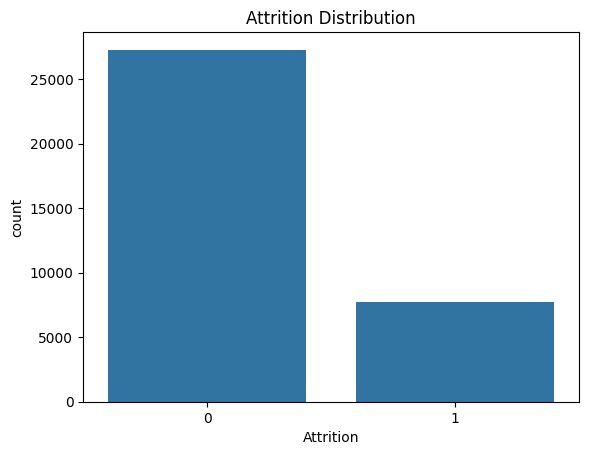

In [ ]:
sns.countplot(data=df, x='Attrition')
plt.title("Attrition Distribution")
plt.show()

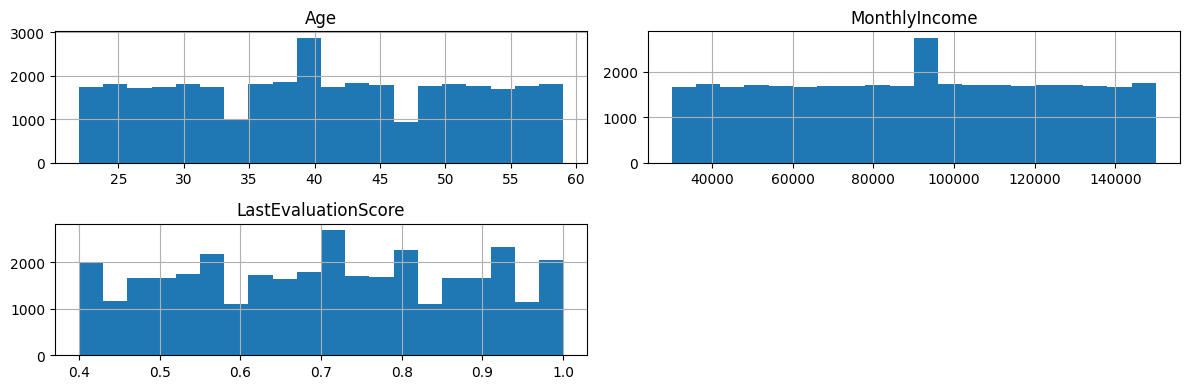

In [ ]:
df[['Age', 'MonthlyIncome', 'LastEvaluationScore']].hist(bins=20, figsize=(12, 4))
plt.tight_layout()
plt.show()

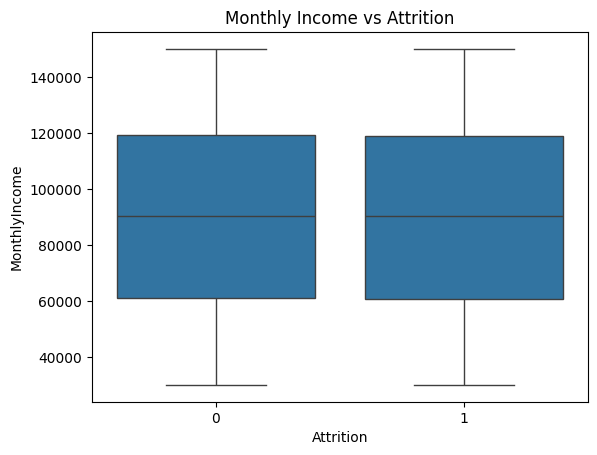

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

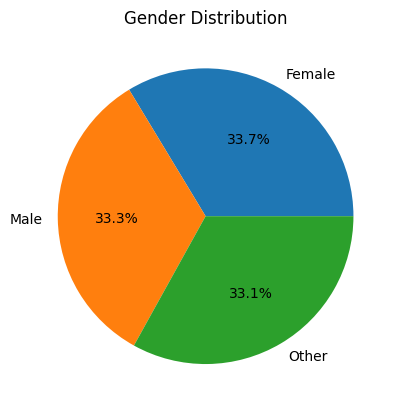

In [ ]:
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

In [ ]:
# STEP 4: Encode categorical features
cat_cols = ['Gender', 'Country', 'Department', 'JobLevel']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])




In [ ]:
# STEP 5: Scale numerical features
X = df.drop(columns=['EmployeeID', 'Attrition'])
y = df['Attrition']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
# STEP 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# STEP 7: Build and compile model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7714 - loss: 0.5525 - val_accuracy: 0.7843 - val_loss: 0.5271
Epoch 2/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7756 - loss: 0.5375 - val_accuracy: 0.7843 - val_loss: 0.5246
Epoch 3/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7791 - loss: 0.5324 - val_accuracy: 0.7843 - val_loss: 0.5241
Epoch 4/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7785 - loss: 0.5324 - val_accuracy: 0.7843 - val_loss: 0.5252
Epoch 5/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7806 - loss: 0.5264 - val_accuracy: 0.7843 - val_loss: 0.5259
Epoch 6/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7779 - loss: 0.5297 - val_accuracy: 0.7843 - val_loss: 0.5243
Epoch 7/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7825 - loss: 0.5240 - val_accuracy: 0.7843 - val_loss: 0.5233
Epoch 8/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7760 - loss: 0.5313 - val_accuracy: 0.7843 - val_

In [ ]:
# STEP 8: Evaluate model
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.7795714285714286
Confusion Matrix:
 [[5456    1]
 [1542    1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88      5457
           1       0.50      0.00      0.00      1543

    accuracy                           0.78      7000
   macro avg       0.64      0.50      0.44      7000
weighted avg       0.72      0.78      0.68      7000



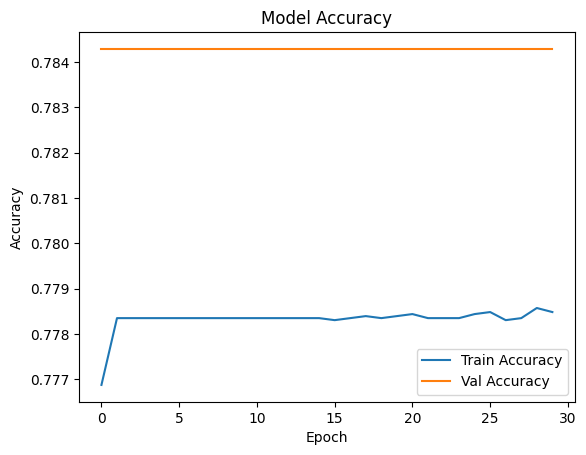

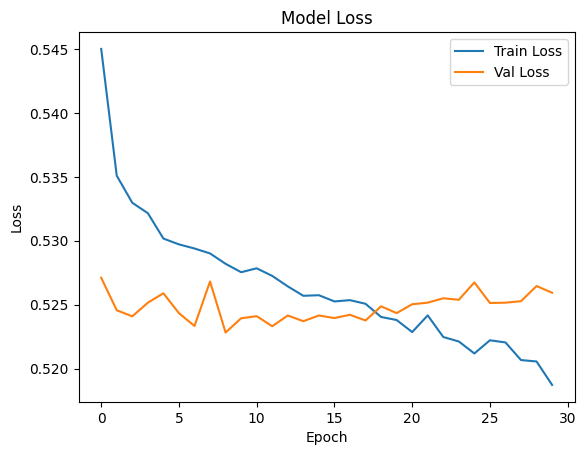

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
